In [1]:
from sklearn.datasets import make_regression
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge
from sklearn.linear_model import ElasticNet

X, y = make_regression(n_samples=2000, n_features=200, random_state=0)

rdg = Ridge(alpha=10)
lss = Lasso(alpha=10)
eln = ElasticNet(alpha=10, l1_ratio=0.7)

rdg.fit(X, y)
lss.fit(X, y)
eln.fit(X, y)

ElasticNet(alpha=10, l1_ratio=0.7)

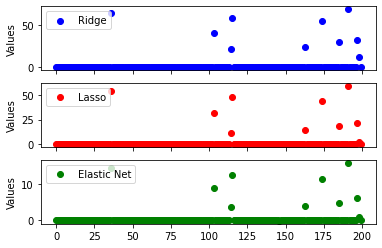

In [2]:
import matplotlib.pyplot as plt

number_of_features = len(rdg.coef_)

f, (ax1, ax2, ax3) = plt.subplots(3, 1, sharex=True)

ax1.scatter(range(number_of_features), rdg.coef_, color='b', label='Ridge')
ax1.set(ylabel='Values')
ax1.legend(loc="upper left")

ax2.scatter(range(number_of_features), lss.coef_, color='r', label='Lasso')
ax2.set(ylabel='Values')
ax2.legend(loc="upper left")

ax3.scatter(range(number_of_features), eln.coef_, color='g', label='Elastic Net')
ax3.set(ylabel='Values')
ax3.legend(loc="upper left")


In [ ]:
import numpy as np

X, y = make_regression(n_samples=2000, n_features=200, random_state=0)

rdg = Ridge()
lss = Lasso()
eln = ElasticNet()

rdg_coefs = [];lss_coefs = []; eln_coefs = []

alphas = np.logspace(-5, 5, 200)

for a in alphas:
    rdg.set_params(alpha=a)
    lss.set_params(alpha=a)
    eln.set_params(alpha=a)
    
    rdg.fit(X, y)
    lss.fit(X, y)
    eln.fit(X, y)
    
    rdg_coefs.append(rdg.coef_)
    lss_coefs.append(lss.coef_)
    eln_coefs.append(eln.coef_)

In [ ]:
f, (ax1, ax2, ax3) = plt.subplots(3, 1, sharex=True)

ax1.plot(rdg_coefs, label='Ridge')
ax1.set(ylabel='Values')
ax1.set(xlabel='Ridge')

ax2.plot(lss_coefs, label='Lasso')
ax2.set(ylabel='Values')
ax2.set(xlabel='Lasso')

ax3.plot(eln_coefs, label='Elastic Net')
ax3.set(ylabel='Values')
ax3.set(xlabel='Elastic Net')

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.datasets import load_diabetes
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import scale

X, y = load_diabetes(return_X_y=True)

pca = PCA()

Z = pca.fit_transform(scale(X))

regr = LinearRegression()
r2scores = []

p = len(Z[1,:])
# Fit to all components one-by-one
for i in np.arange(1, p):
    score = regr.fit(Z[:,:i], y).score(Z[:,:i], y)
    r2scores.append(score)
    

In [ ]:
# Plot results    
sns.set_style("ticks")
plt.plot(np.arange(1, p), r2scores, '-v')
plt.xlabel('Number of Principal Components')
plt.ylabel('R^2')
plt.xlim(xmin=-1);

plt.show()